In [1]:
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt

# Part 1: Exponential family

The exponential family $\mathcal{F}$ is the class of probability distributions with PDF of the form:

$$
p(x | \theta) = h(x) \exp \left[ \eta(\theta)^T T(x) \right]
$$

where $h(.)$ is a non-negative function, $T(.)$ is called sufficient statistics, and $\eta(.)$ the natural parameter.  


### Question 1:

Verify that the exponential distribution, the Poisson distribution and the normal distribution are elements of the exponential family. 

### Question 2:

Write the likelihood of $N$ i.i.d. observations $\lbrace x_1, \dotsc, x_N \rbrace$ for a distribution of the exponential family. 

### Question 3:

Show that the given definition of the exponential family is equivalent to the family of distributions of the form:

$$
p(x | \theta) = f(x) g(\theta) \exp\left[ \phi(\theta)^T u(x) \right]
$$

### Question 4:

Using this equivalent form, show that distributions of the form

$$
    p(\theta) \propto g(\theta)^\eta e^{\phi(\theta)^T \nu}
$$

are conjugate priors for the distributions of the exponential family. 


### Question 5:

Calling $Z(\eta, \nu)$ the normalizing factor of the prior distribution (such that $p(\theta) = Z(\eta, \nu) g(\theta)^\eta e^{\phi(\theta)^T \nu}$, compute the prior predictive checking distribution associated to any distribution of the exponential family. We remind that the prior predictive distribution is given by:

$$
p(x) = \int_\theta p(\theta) p(x | \theta) \, d\theta
$$

# Part 2: Linear regression

As seen in the lecture, the linear regression aims to describe a dataset $\lbrace (x_1, y_1), \dotsc, (x_n, y_n) \rbrace$, with $x_i \in \mathbb{R}^d$ and $y_i \in \mathbb{R}$ as $y_i \simeq w^T x_i$.


## Frequentist approach


In a non-probabilistic vision of machine learning, this is done by assuming a hypothesis class $\mathcal{H} = \lbrace h:x \mapsto w^T x \, | \, w \in \mathbb{R^d} \rbrace$ and considering the quadratic loss $\ell(y, y^\prime) = (y - y^\prime)^2$.

In a probabilistic vision of machine learning, we will consider a generative model for the dataset: 

$$
p(y | x) = \mathcal{N}(y; w^T x, \sigma^2)
$$

We have seen during the lecture (feel free to check it again) that the maximum likelihood estimation of this model is equivalent to the minimization of the quadratic loss in the non-probabilistic vision:

$$
w^* = \text{arg} \min (y - X w)^T (y - X w)
$$

where $X$ is the design matrix and $y$ is the output vector. 

To minimize this quantity, we will compute the gradient $\nabla_w L$ of the loss $L(w) = (y - X w)^T (y - X w)$ and find the $w^*$ for which the gradient vanishes. 

### Question 6: 

Show that, when $X^T X$ is invertible, $w^* = (X^T X)^{-1} X^T y$. For this, we remind that the gradient of a function $f$ satisfies $f(x + h) - f(x) = (\nabla f(x))^T h + o(\|h\|)$.

We illustrate this result using the diabetes dataset available in the scikit-learn library. For visualization purposes, we will consider one single feature in the dataset (instead of the 10 features available in the original dataset.

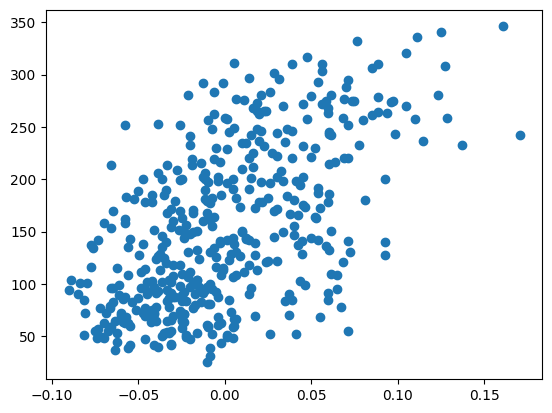

In [2]:
X_diabetes, y_diabetes = datasets.load_diabetes(return_X_y = True)
X = X_diabetes[:, np.newaxis, 2]
y = y_diabetes
plt.scatter(X, y)

As such, the design matrix $X$ contains one single column, which corresponds to the feature of interest. As seen during the lecture, we will consider the intercept not by choosing a model of the form $w^T x + b$, but by adding one extra constant feature to all data points, equal to one. 

### Question 7

Implement this modification of the design matrix

In [3]:
X = np.hstack([X, np.ones((X.shape[0],1))])  # Your code here

### Question 8

Implement a function computing the ML estimator of $w$ using the expression found in Question 6.

*Hint:* In NumPy, you can obtain the transpose of a matrix `A` with `A.T` and the inverse with `np.linalg.inv(A)`. Matrix-matrix or matrix-vector multiplication is carried out with the `@` operator.

In [4]:
def ML_estimator(X, y):
    return np.linalg.inv(X.T @ X) @ X.T @ y

## Bayesian approach


In the Bayesian setting, we consider a prior over the parameter $w$. A typical example of prior could be for instance a Gaussian prior: 

$$
p(w) = \mathcal{N}(w; 0, \Sigma)
$$

### Question 9

Show that the posterior distribution is a multivariate normal. You do not have to compute the mean vector and covariance matrix.


### Question 10

Show that, when $\Sigma = \lambda I$ (with $I$ the identity matrix), the maximum a posteriori corresponds to a non-probabilistic problem with quadratic loss and quadratic regularization. Give an interpretation of this choice of $\Sigma$. 

### Question 11

When doing the Bayesian inference, we compute the posterior $p(w | X, y)$. Propose some solutions to visualize this posterior. 

The code below computes the parameters of the posterior distribution. 

In [5]:
def LR_posterior(X, y, Sigma, sigma2):
    SigmaN = np.linalg.inv(np.linalg.inv(Sigma) + 1/sigma2 * X.T @ X)
    muN = 1/sigma2 * SigmaN @ X.T @ y
    return muN, SigmaN

### Question 12

In the following code, we plot the linear interpolation corresponding to the maximum a posteriori estimation. This idea is contrary to the Bayesian view, though, since it ignores the probabilistic nature of the $w$ coefficient. Using the parameters of the posterior distribution, sample `N` different values of $w$ and add them to the plot. 

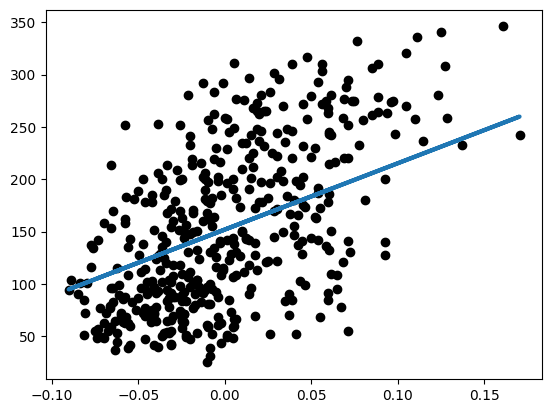

In [6]:
# Hyperparameters:

sigma2 = 500
Sigma = 1000 * np.eye(2)

# Compute the posterior

muN, SigmaN = LR_posterior(X, y, Sigma, sigma2)


plt.figure()
plt.scatter(X[:, 0], y, color="black")

plt.plot(X[:, 0], X @ muN.T, linewidth=3)

N = 10  # Number of samples

# Your code here

plt.show()

### Question 13

How would you adapt the code to polynomial regression?